# JaxFEM – Rechteckstütze 3D (HEX8)

Stütze, beidseits gelenkig gelagert (z=0 und z=Lz), konstante Normalkraft (Drucklast auf Kopfplatte) + kleine Querlast als Imperfektion.

| Parameter | Wert |
|-----------|------|
| Breite b  | 0,3 m (x) |
| Tiefe d   | 0,3 m (y) |
| Höhe H    | 6,0 m (z-Achse, vertikal) |
| Netz      | 10 × 10 × 60 (HEX8) |
| Material  | Beton C40/50, E=35 000 MPa, ν=0,2 |
| Normalkraft | N = 500 kN (Drucklast auf Kopffläche z=H) |
| Querlast | H = 0,5 kN (≈ 0,1 % von N, als Imperfektion) |

> ## JaxFEM API-Regeln
>
> ### `jax_fem.logger_setup`
> - ❌ `logger_setup.setup()` — existiert **nicht**
> - ✅ `logger_setup.setup_logger('jax_fem')`
>
> ### `jax_fem.generate_mesh.box_mesh`
> - ✅ `box_mesh(Nx=Nx, Ny=Ny, Nz=Nz, domain_x=Lx, domain_y=Ly, domain_z=Lz)`
>
> ### Koordinatenachsen (Stütze)
> - x = Querschnittsbreite (0 … b)
> - y = Querschnittstiefe  (0 … d)
> - **z = Stützenhöhe (vertikal, 0 … H)**
> - Fußpunkt: z=0  |  Kopfpunkt: z=H

In [12]:
import jax
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from jax_fem.generate_mesh import Mesh
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem import logger_setup

logger_setup.setup_logger('jax_fem')
print('JAX-Version:', jax.__version__)

JAX-Version: 0.6.2


## 1. Geometrie & Netz

Stütze vertikal: z-Achse = Stützenhöhe. Querschnitt in der x-y-Ebene.

In [13]:
# ── Geometrieparameter ────────────────────────────────────
Lx = 0.3    # m – Querschnittsbreite (x)
Ly = 0.3    # m – Querschnittstiefe  (y)
Lz = 6.0    # m – Stützenhöhe        (z, vertikal)
Nx = 10
Ny = 10
Nz = 60

from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type

ele_type  = 'HEX8'
cell_type = get_meshio_cell_type(ele_type)

meshio_mesh = box_mesh(Nx=Nx, Ny=Ny, Nz=Nz,
                       domain_x=Lx, domain_y=Ly, domain_z=Lz)
mesh   = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
points = meshio_mesh.points

print(f'Netz: {len(points)} Knoten, {len(meshio_mesh.cells_dict[cell_type])} Elemente')
print(f'Δx={Lx/Nx:.3f} m  Δy={Ly/Ny:.3f} m  Δz={Lz/Nz:.3f} m')

Netz: 7381 Knoten, 6000 Elemente
Δx=0.030 m  Δy=0.030 m  Δz=0.100 m


## 2. Material & Lasten

Material: Beton C40/50 (Einheiten: kN + m).  
- **Normalkraft N:** gleichmäßige Drucklast auf Kopffläche (z=Lz), Richtung -z  
- **Querlast H:** gleichmäßige Horizontallast auf Kopffläche (z=Lz), Richtung +x (Imperfektion)

In [14]:
# ── Material (Beton C40/50, kN + m) ──────────────────────
E  = 35_000_000.0   # kN/m² (= 35 000 MPa)
nu = 0.2
mu    = E / (2.0 * (1.0 + nu))
lmbda = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))

# ── Lasten ─────────────────────────────────────────────────
N_total = 500.0          # kN – Gesamtnormalkraft (Druck)
H_total = 0.5            # kN – Gesamtquerlast (Imperfektion, ≈ 0,1 % von N)
A       = Lx * Ly        # m² – Querschnittsfläche

q_N = N_total / A        # kN/m² – Druckspannung auf Kopffläche (gleichmäßig)
q_H = H_total / A        # kN/m² – Horizontalspannung auf Kopffläche

print(f'E={E:.0f} kN/m²  nu={nu}')
print(f'N = {N_total:.1f} kN  →  σ_N = {q_N:.2f} kN/m²')
print(f'H = {H_total:.3f} kN  →  q_H = {q_H:.4f} kN/m²  (Imperfektion ≈ {H_total/N_total*100:.2f} % von N)')

E=35000000 kN/m²  nu=0.2
N = 500.0 kN  →  σ_N = 5555.56 kN/m²
H = 0.500 kN  →  q_H = 5.5556 kN/m²  (Imperfektion ≈ 0.10 % von N)


## 3. Problem-Klasse (lineare Elastizität, 3D)

In [15]:
class LinearElasticity3D(Problem):
    """Lineare Elastizität, 3D (HEX8)."""

    def get_tensor_map(self):
        def stress(u_grad):
            epsilon = 0.5 * (u_grad + u_grad.T)
            sigma   = lmbda * np.trace(epsilon) * np.eye(self.dim) + 2.0 * mu * epsilon
            return sigma
        return stress

    def get_surface_maps(self):
        # Kopffläche z=Lz: Drucklast -z + Horizontallast +x (Imperfektion)
        def load_top(u, x):
            return np.array([q_H, 0.0, -q_N])
        return [load_top]

## 4. Randbedingungen

| Auflager | Position | Typ | Gesperrt |
|----------|----------|-----|----------|
| Fußgelenk | z=0 | Gelenk | u_x, u_y, u_z |
| Kopfgelenk | z=H | Gelenk | u_y, u_z (u_x frei für Horizontallast) |

Beidseits gelenkig (Euler-Knickfall 1): Kopf in x verschiebt sich frei.

In [16]:
tol = min(Lx/Nx, Ly/Ny, Lz/Nz) * 0.6

def zero(point):
    return 0.0

# Fußgelenk: z=0 → alle Translationen fixiert
def at_foot(point):
    return np.isclose(point[2], 0.0, atol=tol)

# Kopfgelenk: z=Lz → u_y, u_z fixiert (u_x frei)
def at_head(point):
    return np.isclose(point[2], Lz, atol=tol)

# Kopffläche: z=Lz → Neumann (Druck + Querlast)
def top_face(point):
    return np.isclose(point[2], Lz, atol=tol)

dirichlet_bc_info = [
    [at_foot, at_foot, at_foot, at_head, at_head],
    [0,       1,       2,       1,       2      ],
    [zero,    zero,    zero,    zero,    zero   ],
]

location_fns = [top_face]

print('Randbedingungen definiert.')
print(f'  Dirichlet: {len(dirichlet_bc_info[0])} Bedingungen  |  Neumann: {len(location_fns)}')

Randbedingungen definiert.
  Dirichlet: 5 Bedingungen  |  Neumann: 1


## 5. Lösen

In [17]:
problem = LinearElasticity3D(
    mesh=mesh,
    vec=3,
    dim=3,
    ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)
sol = solver(problem, solver_options={'umfpack_solver': {}})
print('Lösung berechnet. Shape:', sol[0].shape)

[04-20 04:25:09][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-20 04:25:09][DEBUG] jax_fem: ele_type = HEX8, quad_points.shape = (num_quads, dim) = (8, 3)
[04-20 04:25:09][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (6, 4, 3)
[04-20 04:25:09][DEBUG] jax_fem: Done pre-computations, took 0.26171207427978516 [s]
[04-20 04:25:09][INFO] jax_fem: Solving a problem with 6000 cells, 7381x3 = 22143 dofs.
[04-20 04:25:09][INFO] jax_fem: Element type is HEX8, using 8 quad points per element.
[04-20 04:25:10][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-20 04:25:10][DEBUG] jax_fem: Start timing
[04-20 04:25:10][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-20 04:25:10][DEBUG] jax_fem: Function split_and_compute_cell took 0.0763 seconds
[04-20 04:25:11][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-20 04:25:11][DEBUG] jax_fem: Before, l_2 res = 0.04749999999999999, relative l_2

Lösung berechnet. Shape: (7381, 3)


## 6. Ergebnisse

### 6.1 Verschiebungen – Vergleich mit Balkentheorie

Horizontalverschiebung u_x infolge Querlast H (Einfeldträger-Analogie, beidseits gelenkig):  
w_max = 5·H_lin·H⁴ / (384·E·I)

FEM  u_x,max = 0.3653 mm  (Horizontalverschiebung infolge Imperfektion)
FEM  Δu_z,min = -0.0136 mm  (Stauchung)
Ana. Δu_z = N·H / (E·A) = -0.9524 mm
Ana. u_x,max (EB) = 0.0595 mm
Überhöhungsfaktor: ×41


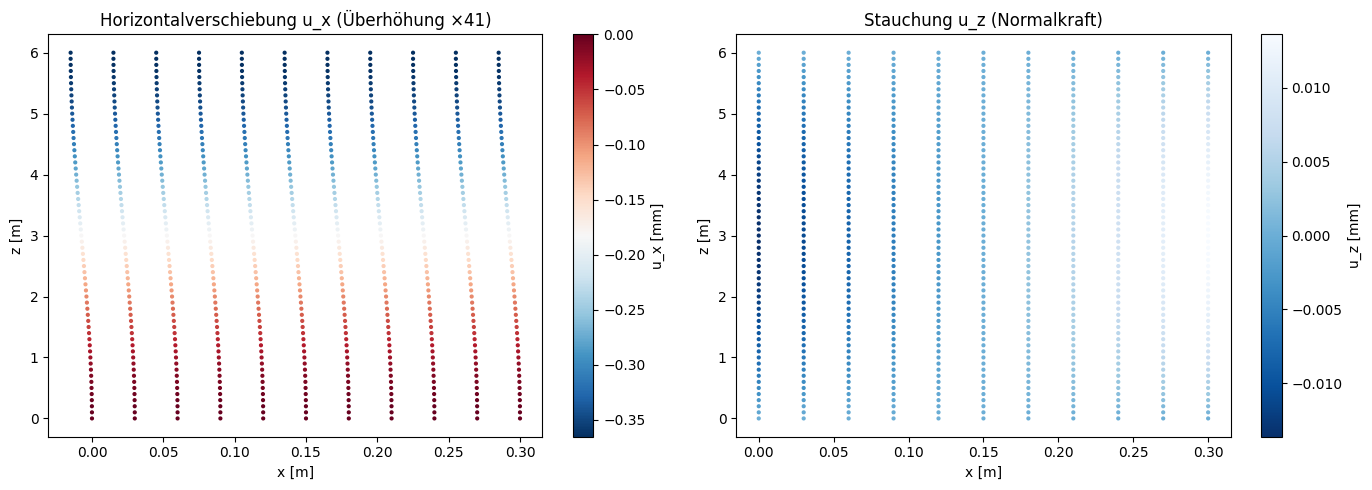

In [18]:
ux = onp.array(sol[0][:, 0])   # Horizontalverschiebung (Imperfektion)
uy = onp.array(sol[0][:, 1])
uz = onp.array(sol[0][:, 2])   # Stauchung in Stützenlängsrichtung

u_max = float(onp.max(onp.abs(ux)))
print(f'FEM  u_x,max = {u_max*1000:.4f} mm  (Horizontalverschiebung infolge Imperfektion)')

# Vertikale Stauchung
duz = float(onp.min(uz))  # uz ist negativ (Druck)
eps_N_ana = -N_total / (E * A)
print(f'FEM  Δu_z,min = {duz*1000:.4f} mm  (Stauchung)')
print(f'Ana. Δu_z = N·H / (E·A) = {eps_N_ana * Lz * 1000:.4f} mm')

# Analytische Biegelinie: Einfeldträger (beidseits gelenkig, Gleichlast in x)
I_y = Ly * Lx**3 / 12    # m⁴ – Flächenträgheitsmoment um y-Achse
H_lin = H_total / Lz      # kN/m – Linienlast in x
ux_mid_ana = 5.0 * H_lin * Lz**4 / (384.0 * E * I_y)
print(f'Ana. u_x,max (EB) = {ux_mid_ana*1000:.4f} mm')

# Mittelschnitt y = Ly/2
mask_mid_y = onp.abs(points[:, 1] - Ly/2) < (Ly/Ny) * 0.8

# Überhöhungsfaktor für Plots (bezogen auf u_x)
scale = min(0.05 * Lx / max(u_max, 1e-10), 200.0)
scale = max(round(scale, 0), 1.0)
print(f'Überhöhungsfaktor: ×{scale:.0f}')

# Verformte Geometrie (xz-Schnitt, y=Ly/2)
x_def = points[:, 0] + scale * ux
z_pts = points[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(x_def[mask_mid_y], z_pts[mask_mid_y],
                      c=ux[mask_mid_y]*1000, cmap='RdBu_r', s=4)
plt.colorbar(sc0, ax=axes[0], label='u_x [mm]')
axes[0].set_title(f'Horizontalverschiebung u_x (Überhöhung ×{scale:.0f})')
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('z [m]')

sc1 = axes[1].scatter(points[mask_mid_y, 0], z_pts[mask_mid_y],
                      c=uz[mask_mid_y]*1000, cmap='Blues_r', s=4)
plt.colorbar(sc1, ax=axes[1], label='u_z [mm]')
axes[1].set_title('Stauchung u_z (Normalkraft)')
axes[1].set_xlabel('x [m]'); axes[1].set_ylabel('z [m]')

plt.tight_layout()
plt.show()

### 6.2 Spannungen (Gauss-Punkt-Extrapolation)

In [19]:
from scipy.spatial import cKDTree

def compute_stress_at_nodes_3d(problem, sol_array, points, cells):
    """Spannungen an Knoten via Gauss-Punkt-Extrapolation (HEX8, 2x2x2)."""
    gp = onp.array([-1/onp.sqrt(3), 1/onp.sqrt(3)])
    gp_triples = [(xi, eta, zeta) for xi in gp for eta in gp for zeta in gp]

    all_gp_coords = []
    all_sigma     = []

    for cell in cells:
        x_cell = points[cell]
        u_cell = sol_array[cell]

        for (xi, eta, zeta) in gp_triples:
            N = 0.125 * onp.array([
                (1-xi)*(1-eta)*(1-zeta), (1+xi)*(1-eta)*(1-zeta),
                (1+xi)*(1+eta)*(1-zeta), (1-xi)*(1+eta)*(1-zeta),
                (1-xi)*(1-eta)*(1+zeta), (1+xi)*(1-eta)*(1+zeta),
                (1+xi)*(1+eta)*(1+zeta), (1-xi)*(1+eta)*(1+zeta),
            ])
            dN_dxi = 0.125 * onp.array([
                [-(1-eta)*(1-zeta), -(1-xi)*(1-zeta), -(1-xi)*(1-eta)],
                [ (1-eta)*(1-zeta), -(1+xi)*(1-zeta), -(1+xi)*(1-eta)],
                [ (1+eta)*(1-zeta),  (1+xi)*(1-zeta), -(1+xi)*(1+eta)],
                [-(1+eta)*(1-zeta),  (1-xi)*(1-zeta), -(1-xi)*(1+eta)],
                [-(1-eta)*(1+zeta), -(1-xi)*(1+zeta),  (1-xi)*(1-eta)],
                [ (1-eta)*(1+zeta), -(1+xi)*(1+zeta),  (1+xi)*(1-eta)],
                [ (1+eta)*(1+zeta),  (1+xi)*(1+zeta),  (1+xi)*(1+eta)],
                [-(1+eta)*(1+zeta),  (1-xi)*(1+zeta),  (1-xi)*(1+eta)],
            ])

            J     = dN_dxi.T @ x_cell
            Jinv  = onp.linalg.inv(J)
            dN_dx = dN_dxi @ Jinv.T
            x_gp  = N @ x_cell
            grad_u = dN_dx.T @ u_cell

            eps = 0.5 * (grad_u + grad_u.T)
            sig = lmbda * onp.trace(eps) * onp.eye(3) + 2 * mu * eps

            all_gp_coords.append(x_gp)
            all_sigma.append(sig.flatten())

    all_gp_coords = onp.array(all_gp_coords)
    all_sigma     = onp.array(all_sigma)
    _, idx = cKDTree(all_gp_coords).query(points)
    return all_sigma[idx].reshape(-1, 3, 3)


cells_hex = meshio_mesh.cells_dict[cell_type]
sigma_nd  = compute_stress_at_nodes_3d(problem, onp.array(sol[0]), points, cells_hex)

szz = sigma_nd[:, 2, 2]   # Normalspannung in Stützenlängsrichtung (Druck)
sxz = sigma_nd[:, 0, 2]   # Schubspannung infolge Querlast
sxx = sigma_nd[:, 0, 0]
syy = sigma_nd[:, 1, 1]
sxy = sigma_nd[:, 0, 1]
syz = sigma_nd[:, 1, 2]
s_vm = onp.sqrt(0.5 * ((sxx-syy)**2 + (syy-szz)**2 + (szz-sxx)**2
                        + 6*(sxy**2 + syz**2 + sxz**2)))

print(f'σ_zz (Druck): min={szz.min():.1f}  max={szz.max():.1f}  kN/m²')
print(f'τ_xz (Schub): min={sxz.min():.1f}  max={sxz.max():.1f}  kN/m²')
print(f'von-Mises max = {s_vm.max():.1f}  kN/m²')
print(f'Ana. σ_N = N/A = {-N_total/A:.1f} kN/m² (Druckspannung)')

σ_zz (Druck): min=-326.9  max=326.9  kN/m²
τ_xz (Schub): min=-45.0  max=28.9  kN/m²
von-Mises max = 306.7  kN/m²
Ana. σ_N = N/A = -5555.6 kN/m² (Druckspannung)


### 6.3 Spannungs-Plots (Mittelschnitt y = Ly/2)

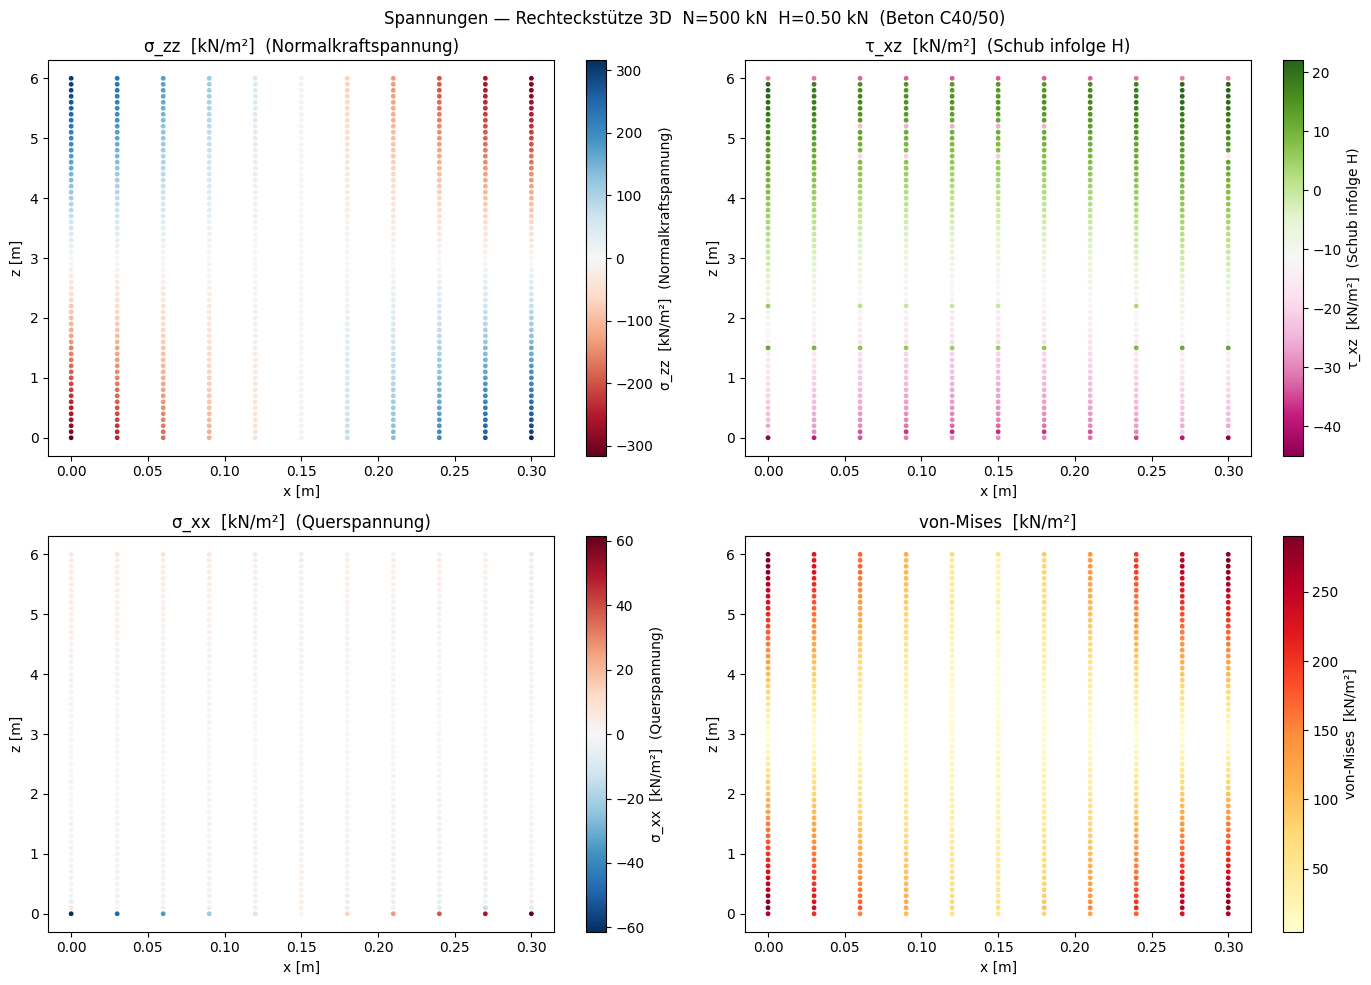

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_plot_pts = points[mask_mid_y, 0]
z_plot_pts = points[mask_mid_y, 2]

plots = [
    (szz[mask_mid_y], 'σ_zz  [kN/m²]  (Normalkraftspannung)',  'RdBu'),
    (sxz[mask_mid_y], 'τ_xz  [kN/m²]  (Schub infolge H)',       'PiYG'),
    (sxx[mask_mid_y], 'σ_xx  [kN/m²]  (Querspannung)',          'RdBu_r'),
    (s_vm[mask_mid_y], 'von-Mises  [kN/m²]',                    'YlOrRd'),
]

for ax, (data, label, cmap) in zip(axes, plots):
    sc = ax.scatter(x_plot_pts, z_plot_pts, c=data, cmap=cmap, s=6)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set_title(label)
    ax.set_xlabel('x [m]'); ax.set_ylabel('z [m]')

plt.suptitle(f'Spannungen — Rechteckstütze 3D  N={N_total:.0f} kN  H={H_total:.2f} kN  (Beton C40/50)', fontsize=12)
plt.tight_layout()
plt.show()

### 6.4 Schnittgrößen über Stützenhöhe

- **N(z):** konstant = −N_total (Druckkraft)
- **V(z):** aus Querlast H (gleichmäßig verteilt als Imperfektion)
- **M(z):** aus V, beidseits gelenkig → parabolisch

Normalkraft  N = 500.0 kN (konstant, Druck)
Querlast-Linie RA = RB = 0.2500 kN
M_max (Mitte) = 0.37500 kNm


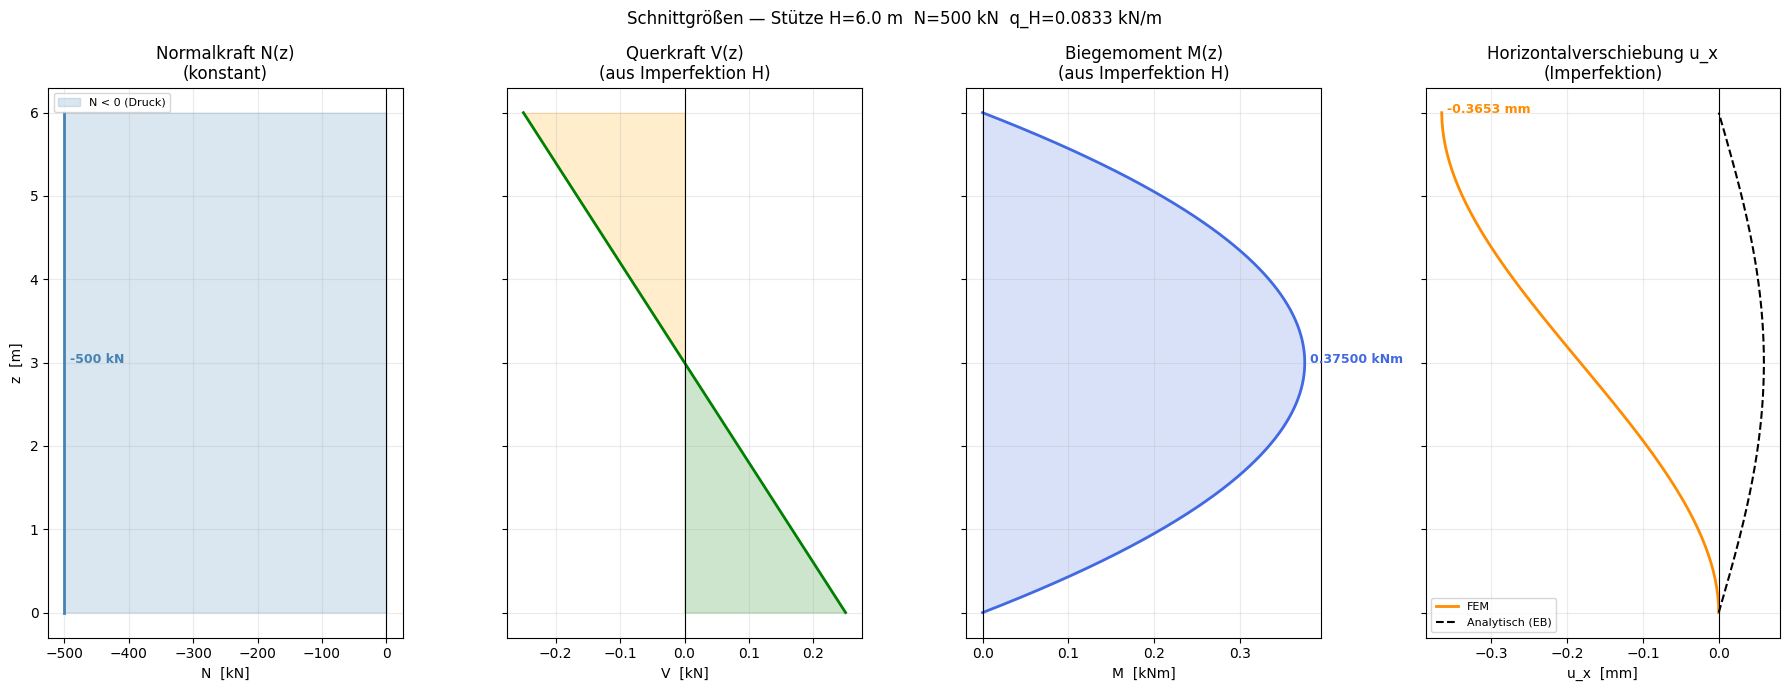

In [21]:
z_plot = onp.linspace(0, Lz, 1000)

# Analytische Schnittgrößen (beidseits gelenkig, gleichmäßige Querlast H_lin)
H_lin = H_total / Lz        # kN/m – Linienlast in x-Richtung
RA_x  = H_lin * Lz / 2     # kN – Auflagerreaktion Fußpunkt in x
RB_x  = H_lin * Lz / 2     # kN – Auflagerreaktion Kopfpunkt in x

N_vals = -N_total * onp.ones_like(z_plot)          # konstante Drucknormalkraft
V_vals = RA_x - H_lin * z_plot                     # Querkraft
M_vals = RA_x * z_plot - H_lin * z_plot**2 / 2     # Biegemoment
M_max  = H_lin * Lz**2 / 8

print(f'Normalkraft  N = {-N_vals[0]:.1f} kN (konstant, Druck)')
print(f'Querlast-Linie RA = RB = {RA_x:.4f} kN')
print(f'M_max (Mitte) = {M_max:.5f} kNm')

# FEM-Horizontalverschiebung entlang Stützenhöhe (Mittelachse x=Lx/2, y=Ly/2)
tol_mid_xy = min(Lx/Nx, Ly/Ny) * 0.8
mask_axis  = (onp.abs(points[:, 0] - Lx/2) < tol_mid_xy) & \
             (onp.abs(points[:, 1] - Ly/2) < tol_mid_xy)
z_ax  = points[mask_axis, 2]
ux_ax = ux[mask_axis]
sort_z = onp.argsort(z_ax)
z_ax  = z_ax[sort_z]; ux_ax = ux_ax[sort_z]

# Analytische Biegelinie (beidseits gelenkig, gleichmäßige Last)
z_a  = onp.linspace(0, Lz, 500)
ux_a = H_lin * z_a * (Lz**3 - 2*Lz*z_a**2 + z_a**3) / (24 * E * I_y)

fig, axes = plt.subplots(1, 4, figsize=(18, 7), sharey=True)
fig.suptitle(f'Schnittgrößen — Stütze H={Lz} m  N={N_total:.0f} kN  q_H={H_lin:.4f} kN/m', fontsize=12)

# ① Normalkraft
ax = axes[0]
ax.plot(N_vals, z_plot, color='steelblue', lw=2)
ax.fill_betweenx(z_plot, 0, N_vals, alpha=0.2, color='steelblue', label='N < 0 (Druck)')
ax.axvline(0, color='black', lw=0.8)
ax.annotate(f'{N_vals[0]:.0f} kN', xy=(N_vals[0], Lz/2),
            xytext=(4, 0), textcoords='offset points', fontsize=9, color='steelblue', fontweight='bold')
ax.set_xlabel('N  [kN]'); ax.set_ylabel('z  [m]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
ax.set_title('Normalkraft N(z)\n(konstant)')

# ② Querkraft
ax = axes[1]
ax.plot(V_vals, z_plot, color='green', lw=2)
ax.fill_betweenx(z_plot, 0, V_vals, where=(V_vals>=0), alpha=0.2, color='green')
ax.fill_betweenx(z_plot, 0, V_vals, where=(V_vals< 0), alpha=0.2, color='orange')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('V  [kN]')
ax.grid(True, alpha=0.25)
ax.set_title('Querkraft V(z)\n(aus Imperfektion H)')

# ③ Biegemoment
ax = axes[2]
ax.plot(M_vals, z_plot, color='royalblue', lw=2)
ax.fill_betweenx(z_plot, 0, M_vals, alpha=0.2, color='royalblue')
ax.axvline(0, color='black', lw=0.8)
i_max = onp.argmax(M_vals)
ax.annotate(f'{M_vals[i_max]:.5f} kNm', xy=(M_vals[i_max], z_plot[i_max]),
            xytext=(4, 0), textcoords='offset points', fontsize=9, color='royalblue', fontweight='bold')
ax.set_xlabel('M  [kNm]')
ax.grid(True, alpha=0.25)
ax.set_title('Biegemoment M(z)\n(aus Imperfektion H)')

# ④ Horizontalverschiebung (FEM vs. Analytisch)
ax = axes[3]
ax.plot(ux_ax * 1000, z_ax, color='darkorange', lw=2, label='FEM')
ax.plot(ux_a * 1000,  z_a,  'k--', lw=1.5, label='Analytisch (EB)')
ax.axvline(0, color='black', lw=0.8)
i_u = onp.argmax(onp.abs(ux_ax))
ax.annotate(f'{ux_ax[i_u]*1000:.4f} mm', xy=(ux_ax[i_u]*1000, z_ax[i_u]),
            xytext=(4, 0), textcoords='offset points', fontsize=9, color='darkorange', fontweight='bold')
ax.set_xlabel('u_x  [mm]')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
ax.set_title('Horizontalverschiebung u_x\n(Imperfektion)')

plt.tight_layout()
plt.show()

### 6.5 Spannungsverteilung σ_zz über Querschnitt (FEM vs. Analytisch)

σ_zz = −N/A ± M·z_s/I  (Normalkraft + Biegeanteil aus Imperfektion)

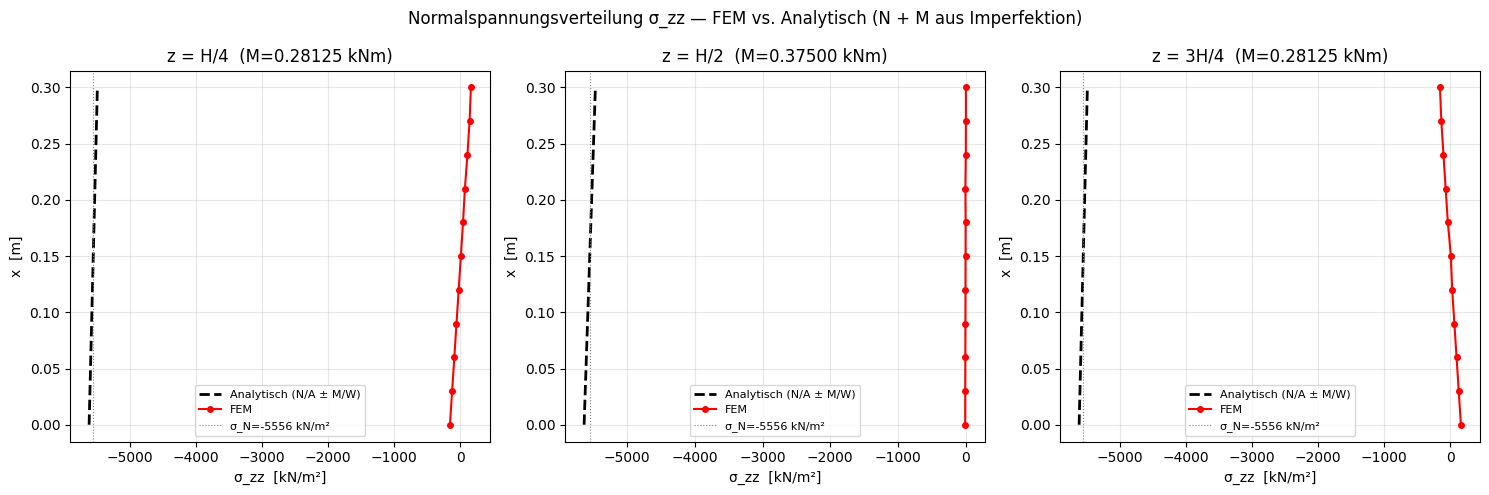

In [22]:
tol_z_cut = (Lz / Nz) * 0.8

z_cuts = {
    'z = H/4': Lz / 4,
    'z = H/2': Lz / 2,
    'z = 3H/4': 3 * Lz / 4,
}

x_neutral = Lx / 2
I_y_qs    = Ly * Lx**3 / 12   # Flächenträgheitsmoment um y-Achse

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (label, z_cut) in zip(axes, z_cuts.items()):
    mask_z = (onp.abs(points[:, 2] - z_cut) < tol_z_cut) & mask_mid_y
    x_fem  = points[mask_z, 0]
    szz_s  = szz[mask_z]
    sort_i = onp.argsort(x_fem)

    M_ana     = RA_x * z_cut - H_lin * z_cut**2 / 2
    x_vals    = onp.linspace(0, Lx, 200)
    sigma_ana = -N_total / A + M_ana * (x_vals - x_neutral) / I_y_qs

    ax.plot(sigma_ana, x_vals, 'k--', lw=2, label='Analytisch (N/A ± M/W)')
    ax.plot(szz_s[sort_i], x_fem[sort_i], 'ro-', ms=4, label='FEM')
    ax.axvline(-N_total/A, color='gray', lw=0.8, ls=':', label=f'σ_N={-N_total/A:.0f} kN/m²')
    ax.set_xlabel('σ_zz  [kN/m²]')
    ax.set_ylabel('x  [m]')
    ax.set_title(f'{label}  (M={M_ana:.5f} kNm)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Normalspannungsverteilung σ_zz — FEM vs. Analytisch (N + M aus Imperfektion)', fontsize=12)
plt.tight_layout()
plt.show()